In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/diamonds.csv.zip')

In [3]:
df.sample(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
1567,1568,0.73,Ideal,H,VVS1,61.6,57.0,3005,5.81,5.78,3.57
10990,10991,0.91,Very Good,G,VVS2,62.1,60.0,4913,6.14,6.19,3.83
43828,43829,0.51,Good,F,VS2,63.1,59.0,1444,5.04,5.10,3.20
30894,30895,0.35,Ideal,E,VS2,61.6,57.0,744,4.53,4.56,2.80
41424,41425,0.54,Ideal,H,SI1,62.5,53.0,1227,5.22,5.25,3.27


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df.shape

(53940, 11)

In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0


In [7]:
df.describe()

,Unnamed: 0,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,26970.500000,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,15571.281097,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,1.000000,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,13485.750000,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,26970.500000,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,40455.250000,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,53940.000000,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
num_col = df.select_dtypes(include='number').columns
cat_col = df.select_dtypes(include='object').columns

### EDA

<Axes: xlabel='cut', ylabel='price'>

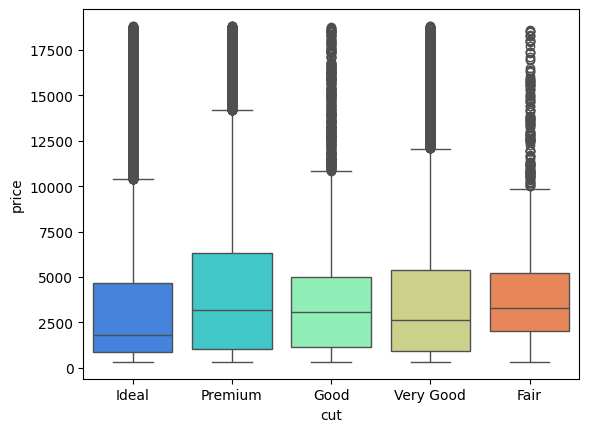

In [9]:
sns.boxplot(x='cut',y='price',data=df,palette='rainbow')

<Axes: xlabel='color', ylabel='price'>

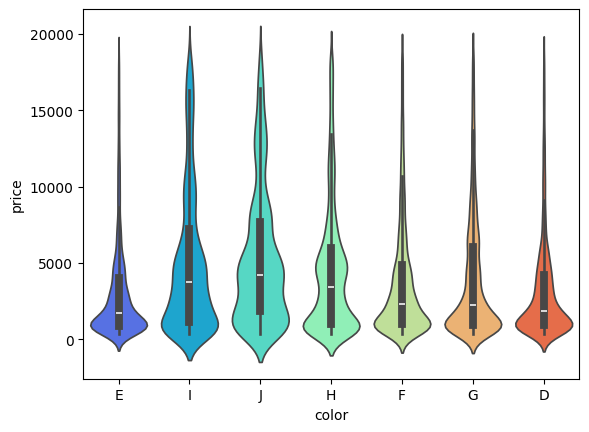

In [10]:
sns.violinplot(x='color',y='price',data=df,palette='rainbow')

<Axes: xlabel='clarity', ylabel='price'>

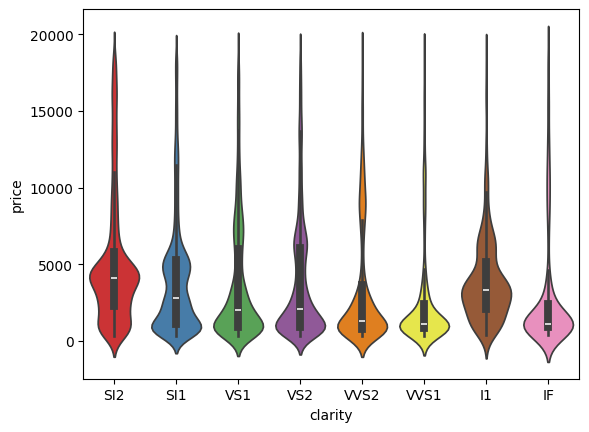

In [11]:
sns.violinplot(x='clarity',y='price',data=df,palette='Set1')

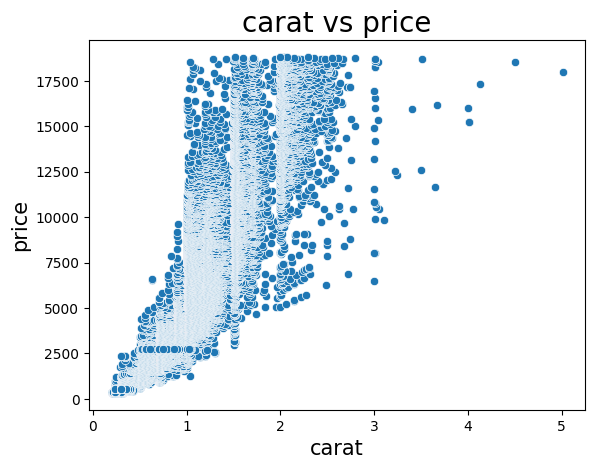

In [12]:
sns.scatterplot(x='carat',y='price',data=df)
plt.xlabel('carat',fontsize=15)
plt.ylabel('price',fontsize=15)
plt.title('carat vs price',fontsize=20)
plt.show()

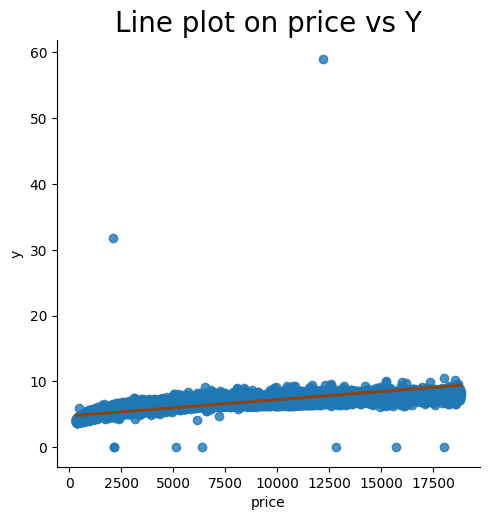

In [13]:
## checking the outliers
sns.lmplot(x='price',y='y',data=df,line_kws={"color": "#8B4513"})
plt.title('Line plot on price vs Y', fontsize=20)
plt.show()

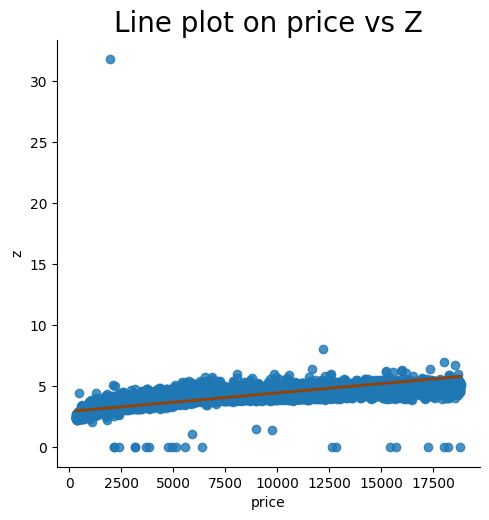

In [14]:
sns.lmplot(x='price',y='z',data=df,line_kws={"color": "#8B4513"})
plt.title('Line plot on price vs Z', fontsize=20)
plt.show()

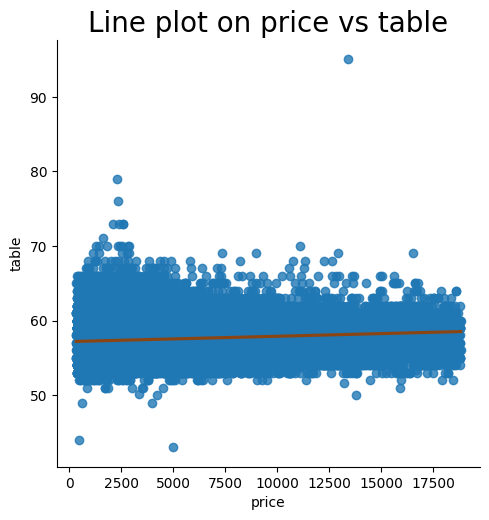

In [15]:
sns.lmplot(x='price',y='table',data=df,line_kws={"color": "#8B4513"})
plt.title('Line plot on price vs table', fontsize=20)
plt.show()

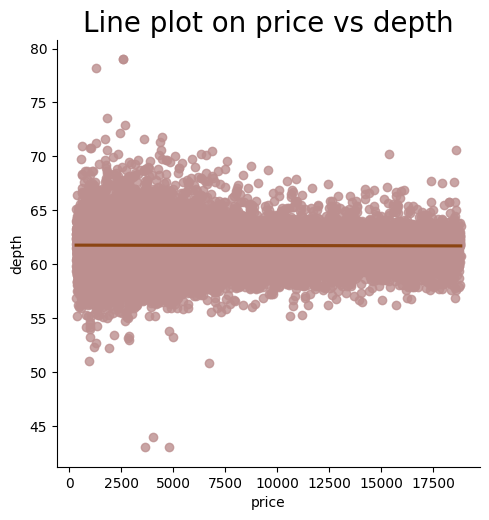

In [16]:
sns.lmplot(x='price',y='depth',data=df,line_kws={"color": "#8B4513"},scatter_kws={'color':'#BC8F8F'})
plt.title('Line plot on price vs depth', fontsize=20)
plt.show()

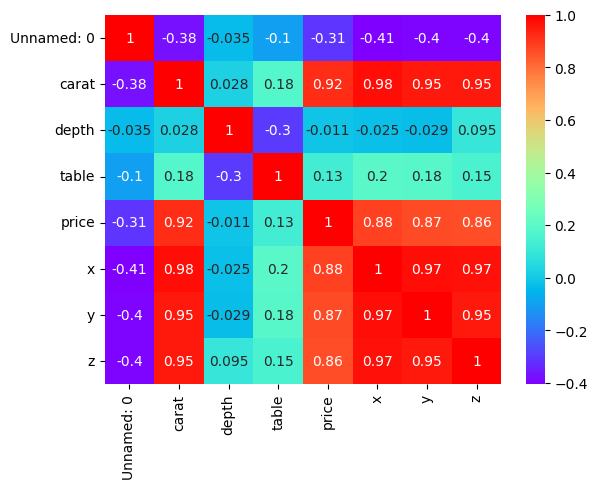

In [17]:
num_col = df.select_dtypes(include='number').columns
sns.heatmap(data=df[num_col].corr(),annot=True,cmap='rainbow')
plt.show()

In [18]:
## Data cleaning
df = df.drop(['Unnamed: 0'],axis=1)

In [19]:
# removing the datapoints having min 0 values in either x,y,z
df = df.drop(df[df['x']==0].index)
df = df.drop(df[df['y']==0].index)
df = df.drop(df[df['z']==0].index)
df.shape

(53920, 10)

In [23]:
# dropping the outlier from
df = df[(df["table"]<80)&(df["table"]>40)]
df = df[(df["depth"]<75)&(df["depth"]>45)]
df = df[(df["x"]<40)]
df = df[(df["y"]<40)]
df = df[(df["z"]<40)&(df["z"]>2)]
df.shape

(53907, 10)

In [24]:
# Encoding the categorical variables
# creating a copy
data = df.copy()

In [26]:
from sklearn.preprocessing import LabelEncoder
columns = ['cut','color','clarity']
le = LabelEncoder()
for col in columns:
  data[col] = le.fit_transform(data[col])
data.describe()


,carat,cut,color,clarity,depth,table,price,x,y,z
count,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000,53907.000000
mean,0.797622,2.553379,2.593949,3.835569,61.749702,57.456369,3930.558017,5.731456,5.733779,3.540001
std,0.473762,1.027442,1.701269,1.724572,1.420103,2.224584,3987.189327,1.119366,1.116890,0.702085
min,0.200000,0.000000,0.000000,0.000000,50.800000,49.000000,326.000000,3.730000,3.680000,2.060000
25%,0.400000,2.000000,1.000000,2.000000,61.000000,56.000000,949.000000,4.710000,4.720000,2.910000
50%,0.700000,2.000000,3.000000,4.000000,61.800000,57.000000,2400.000000,5.700000,5.710000,3.530000
75%,1.040000,3.000000,4.000000,5.000000,62.500000,59.000000,5322.000000,6.540000,6.540000,4.040000
max,5.010000,4.000000,6.000000,7.000000,73.600000,79.000000,18823.000000,10.740000,31.800000,31.800000


<Axes: >

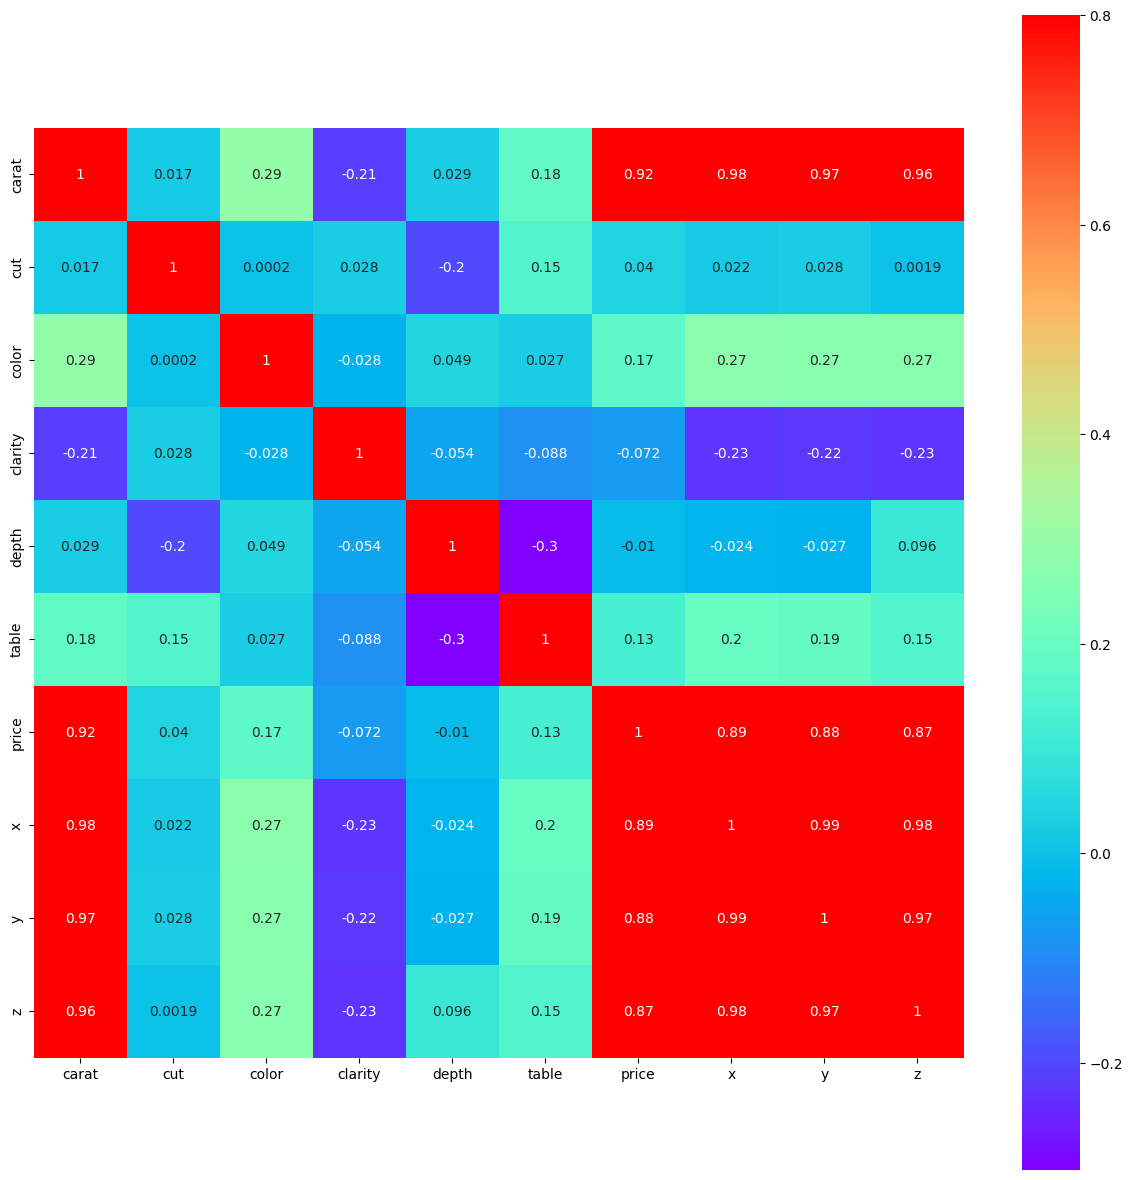

In [27]:
# correlation matrix
sns.diverging_palette(70,20,s=50,l=40,n=6,as_cmap=True)
corrmat = data.corr()
f,ax = plt.subplots(figsize=(15,15))
sns.heatmap(corrmat,vmax=.8,square=True,annot=True,cmap='rainbow')

### model building

In [32]:
from sklearn.model_selection import train_test_split
X = data.drop(['price'],axis=1)
y = data['price']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.20)

### Building pipeline for model

In [33]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.tree import DecisionTreeRegressor # Corrected import
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

pipeline_lr = Pipeline([("scalar1",StandardScaler()),
                        ('lr',LinearRegression())])

pipeline_lasso = Pipeline([("scaler2",StandardScaler()),
                           ('lasso',Lasso())])

pipeline_dt = Pipeline([('scaler3',StandardScaler()),
                       ('dt',DecisionTreeRegressor()) ]) # Corrected pipeline step

pipeline_rf = Pipeline([('scaler4',StandardScaler()),
                        ('rf',RandomForestRegressor())]) # Added tuple for 'rf'

pipeline_knn = Pipeline([('scaler5',StandardScaler()),
                         ('knn',KNeighborsRegressor())])

pipeline_xgb = Pipeline([('scaler6',StandardScaler()),
                        ('xgb',XGBRegressor())])

pipelines = [pipeline_lr,pipeline_lasso,pipeline_dt,pipeline_rf,pipeline_knn,pipeline_xgb]

# making dictionary of pipeline
pipe_dict = {0:'LinearRegression',1:'Lasso',2:'DecisionTree',3:'RandomForest',4:'KNeighborsRegressor',5:'XGBRegressor'}

for pipe in pipelines:
  pipe.fit(X_train,y_train)

In [35]:
from sklearn.model_selection import cross_val_score
cv_result_rms = []
for i,model in enumerate(pipelines):
  cv_score = cross_val_score(model,X_train,y_train,scoring='neg_mean_squared_error',cv=10)
  cv_result_rms.append(np.sqrt(np.abs(cv_score)))
  print("%s: %f " % (pipe_dict[i], -1 * cv_score.mean()))

LinearRegression: 2320623.208052 
Lasso: 2003150.433423 
DecisionTree: 557043.433158 
RandomForest: 304927.880858 
KNeighborsRegressor: 666791.518981 
XGBRegressor: 301715.375000 


In [38]:
import sklearn.metrics as metrics

# Make predictions using one of the trained models, for example, RandomForest
pred = pipelines[3].predict(X_test) # pipelines[3] corresponds to RandomForest

# Model Evaluation
print("R^2:",metrics.r2_score(y_test, pred))
print("Adjusted R^2:",1 - (1-metrics.r2_score(y_test, pred))*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))
print("MAE:",metrics.mean_absolute_error(y_test, pred))
print("MSE:",metrics.mean_squared_error(y_test, pred))
print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test, pred)))

R^2: 0.9811876532067753
Adjusted R^2: 0.9811719355015079
MAE: 268.9279938919363
MSE: 286168.18473536376
RMSE: 534.9468989865852
